<a href="https://colab.research.google.com/github/Maddox24425/ML-with-Keras-and-Tesnsrflow/blob/main/Chapter_10_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
print("hello world")

hello world


In [4]:
import sys

assert sys.version_info >= (3, 7)

In [5]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__)>=version.parse("1.0.1")

In [6]:
import tensorflow as tf

assert version.parse(tf.__version__)>=version.parse("2.8.0")

In [7]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [8]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ann"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [10]:
mnist=tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
X_train.shape

(55000, 28, 28)

In [12]:
X_train.dtype

dtype('uint8')

In [ ]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

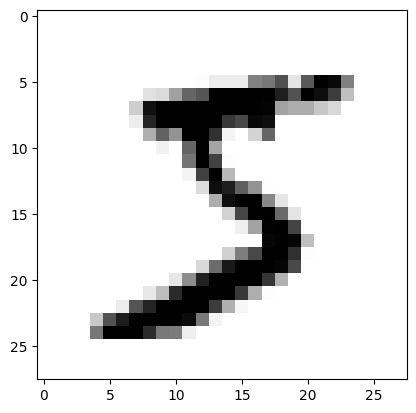

In [13]:
plt.imshow(X_train[0], cmap="binary")
# plt.axis('off')
plt.show()

In [14]:
class_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

In [15]:
class_names[y_train[0]]

'5'

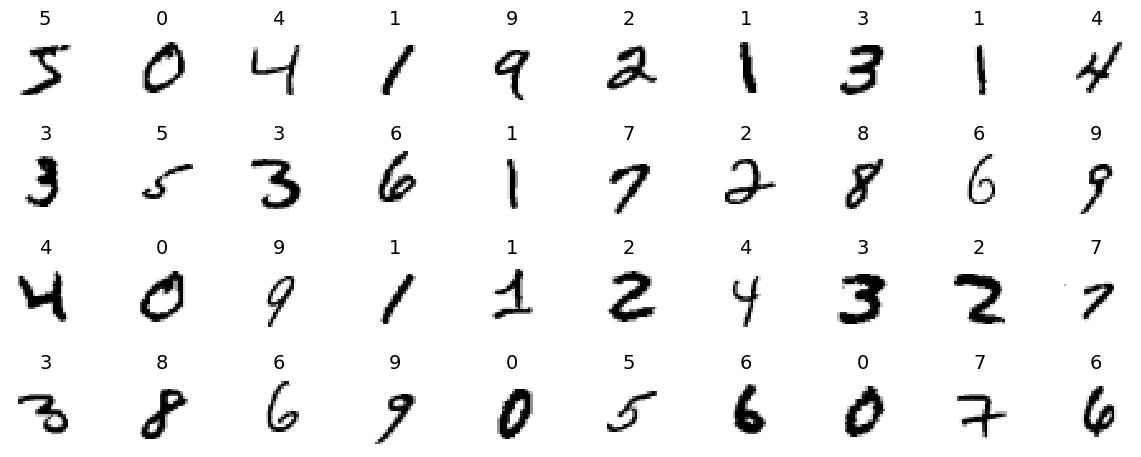

In [16]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

save_fig("mnist_plot")
plt.show()

In [17]:
tf.random.set_seed(42)

In [18]:
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
#compiling here.

optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [20]:
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid))

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.7648 - loss: 1.4515 - val_accuracy: 0.8998 - val_loss: 0.3712
